Brianna Lannerd
08/26/2026
Lab 1 - Projectile Motion Solver

In [39]:
import numpy as np
import matplotlib.pyplot as plt



In [40]:
def simulate_freefall (h,dt,g=9.81):
    state = np.array([h,0])
    y=h
    vy=0
    t=0
    ys, ts, vys = [y],[0],[vy]
    while y >= 0:
        vy = vy - g * dt
        y = y+ vy * dt
        t += dt
        ys.append(y)
        vys.append(vy)
        ts.append(t)
    return np.array(ts), np.array(ys), np.array(vys)
h=100
dt=0.1
g=9.81
ts, ys, vys = simulate_freefall(h,dt,g)


In [41]:
# Exact Solution Equations
y_exact = h - 0.5 * g * ts**2
tf=np.sqrt(2*h/g)
v_exact = -g * ts

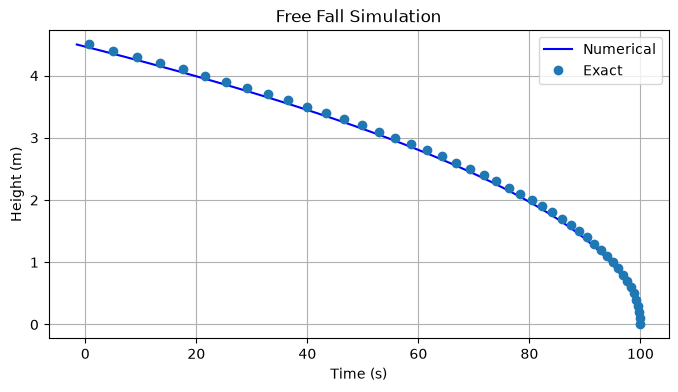

In [42]:
plt.figure(figsize=(8,4))
plt.plot(ys,ts, '-b', label='Numerical')
plt.plot(y_exact,ts, 'o', label='Exact')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Free Fall Simulation')
plt.grid(True)
plt.legend()
plt.show()

In [43]:
def simulate_projectile_2d (v0, theta_deg,dt,g):
    x=0
    y=0
    vx=v0*np.cos(np.radians(theta_deg))
    vy=v0*np.sin(np.radians(theta_deg))
    t=0

    #Storage Lists for plotting
    ts, xs, ys, vxs, vys = [0], [0], [0], [v0*np.cos(np.radians(theta_deg))], [v0*np.sin(np.radians(theta_deg))]

    #Euler Loop
        
    while y >= 0:
        ax=0.0
        ay=-g

        #Update Veloctiy
        vy = vy + ay * dt
        vx= vx+ ax*dt
        #Update Position
        x = x + vx * dt
        y = y+ vy * dt
            
        t += dt
        xs.append(x)
        ys.append(y)
        vxs.append(vx)
        vys.append(vy)
        ts.append(t)
    return np.array(xs), np.array(ys), np.array(vys), np.array(vxs), np.array(ts)
v0=30
theta_deg=45

dt = 0.01
g=9.81
xs, ys, vxs, vys,ts = simulate_projectile_2d(v0, theta_deg, dt, g)

range = v0**2 * np.sin(2*np.radians(theta_deg)) / g
max_height = (v0**2 * np.sin(np.radians(theta_deg))**2) / (2*g)
flight_time = 2*v0*np.sin(np.radians(theta_deg))/g

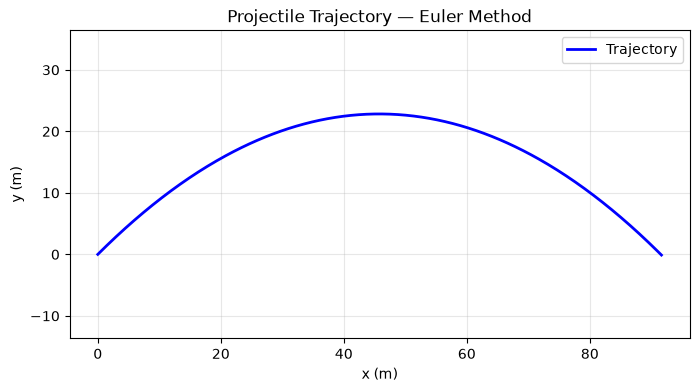

In [44]:
plt.figure(figsize=(8, 4))
plt.plot(xs, ys, 'b-', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend(['Trajectory'])
plt.axis('equal')
plt.show()


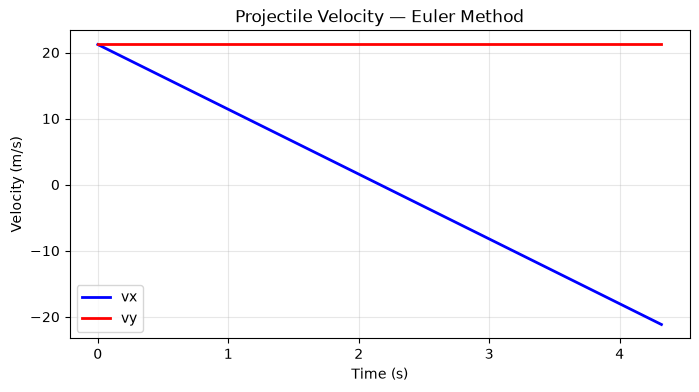

In [45]:
plt.figure(figsize=(8, 4))
plt.plot(ts, vxs, 'b-', label='vx', linewidth=2)
plt.plot(ts, vys, 'r-', label='vy', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Projectile Velocity — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [46]:
theta_rad = np.radians(theta_deg)
exact_range = 91.74
exact_max_height = 22.94
exact_flight_time = 4.324
numerical_range = xs[-1]
numerical_max_height = max(ys)
numerical_flight_time = ts[-1]
range_error = abs((exact_range - numerical_range) / exact_range) * 100
height_error = abs((exact_max_height - numerical_max_height) / exact_max_height) * 100
time_error = abs((exact_flight_time - numerical_flight_time) / exact_flight_time) * 100
print(f"range error =", range_error, "%")
print(f"height error =", height_error, "%")
print(f"time error =", time_error, "%")


range error = 0.10787133008887209 %
height error = 0.4803686970864736 %
time error = 0.09250693802145053 %


In [47]:
angles = np.arange(10, 85, 5)
ranges = []
for angle in angles:
    ts, xs, ys, vxs, vys = simulate_projectile_2d(v0, angle, dt, g)

    projectile_range = xs[-1]
    ranges.append(projectile_range)

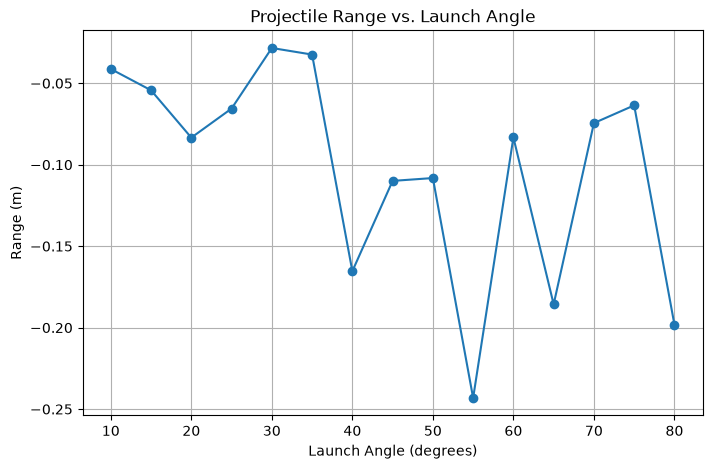

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(angles, ranges, marker="o")

plt.xlabel("Launch Angle (degrees)")
plt.ylabel("Range (m)")
plt.title("Projectile Range vs. Launch Angle")
plt.grid()

plt.show()